# EDA V2 — Analyse Exploratoire des Données

---

## Pipeline EDA

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Chargement | 2 | Charger `data.csv` + nettoyage noms colonnes (`str.strip()`) |
| Statistiques descriptives | 3 | mean, std, min, max, quartiles |
| Aperçu global | 4 | Shape, types, `df.info()` |
| Qualité des données | 5 | NaN + doublons via `check_data_quality()` |
| Séparation variables | 6 | `CATEGORICAL_VARS` (modalités <= 6) + `NUMERICAL_VARS` |
| Variable cible | 7 | Distribution stroke — déséquilibre 92% vs 8% |
| Distribution catégorielles | 8 | Countplot avec labels lisibles pour chaque variable |
| Distribution continues | 9 | Histogramme + KDE + code couleur skewness |
| Outliers | 10 | Boxplots + % quantifié par variable -> justifie Winsorization |
| Skewness | 11 | Tableau coloré + seuil |skew| > 2 -> justifie Log1p |
| Corrélation avec target | 12 | Barplot de toutes les variables (cat + num) avec stroke |
| Heatmap complète | 13 | Corrélation inter-features -> justifie VIF en modeling |
| Sauvegarde | 14 | `save_features()` -> génère `features.json` |

---

**Sortie** : `src/features.json` — chargé par `2_Preprocessing_v2.ipynb` et `3_Modeling_v2.ipynb`

## 1. Imports & Configuration

In [1]:
import sys
sys.path.insert(0, './src')
import importlib, config
importlib.reload(config)
from config import (
    TARGET, RANDOM_STATE, DATA_PATH,
    LABEL_MAPS, EXPECTED_VALUES,
    check_data_quality, save_features
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('Librairies importées avec succès !')

Librairies importées avec succès !


## 2. Chargement du jeu de données
Nous chargeons notre fichier `data.csv` contenant les données cliniques, démographiques et comportementales des patients pour l'étude sur les AVC (Stroke).

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f'Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Variable cible : stroke → {df[TARGET].value_counts().to_dict()}')
df.head()

Shape : 4603 lignes × 36 colonnes
Variable cible : stroke → {0: 4241, 1: 362}


,stroke,gender,age,Race,Marital status,alcohol,smoke,sleep disorder,Health Insurance,General health condition,...,energy,protein,Carbohydrate,Dietary fiber,Total fat,Total saturated fatty acids,Total monounsaturated fatty acids,Total polyunsaturated fatty acids,Potassium,Sodium
0,0,2,2,5,1,0,0,2,2,3,...,1598,62.78,192.19,10.0,65.64,25.112,24.090,8.543,2887,2969
1,0,2,2,1,1,0,0,1,2,3,...,1547,45.35,256.02,17.0,42.56,13.423,15.389,10.613,2058,2091
2,1,1,2,3,1,1,1,2,1,3,...,2466,81.56,254.49,13.0,103.32,43.295,36.727,15.366,3117,5233
3,0,2,3,3,1,1,1,2,1,4,...,1605,70.99,143.37,10.0,81.60,24.527,30.567,18.174,1766,3706
4,0,1,1,4,1,0,0,2,1,2,...,1818,74.75,229.45,14.2,67.49,26.030,24.837,10.533,1842,2461


## 3. Statistiques descriptives
Nous allons observer la distribution statistique (moyenne, écart-type, minimum, maximum, quartiles) des variables numériques pour repérer d'éventuelles valeurs aberrantes (outliers).

In [3]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
stroke,4603.0,0.078644,0.269212,0.000,0.000000,0.000000,0.000000,1.000
gender,4603.0,1.545297,0.497998,1.000,1.000000,2.000000,2.000000,2.000
age,4603.0,2.244840,0.663028,1.000,2.000000,2.000000,3.000000,3.000
Race,4603.0,3.066913,1.040195,1.000,3.000000,3.000000,4.000000,5.000
Marital status,4603.0,2.277211,1.633677,1.000,1.000000,1.000000,3.000000,6.000
alcohol,4603.0,0.726917,0.445591,0.000,0.000000,1.000000,1.000000,1.000
smoke,4603.0,0.521834,0.499577,0.000,0.000000,1.000000,1.000000,1.000
sleep disorder,4603.0,1.752118,0.431830,1.000,2.000000,2.000000,2.000000,2.000
Health Insurance,4603.0,1.128829,0.335047,1.000,1.000000,1.000000,1.000000,2.000
General health condition,4603.0,3.207691,0.928969,1.000,3.000000,3.000000,4.000000,5.000


## 4. Aperçu global — types et dimensions

In [4]:
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Variable cible : stroke → {df[TARGET].value_counts().to_dict()}')
df.info()

Dimensions : 4603 lignes × 36 colonnes
Variable cible : stroke → {0: 4241, 1: 362}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4603 entries, 0 to 4602
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   stroke                             4603 non-null   int64  
 1   gender                             4603 non-null   int64  
 2   age                                4603 non-null   int64  
 3   Race                               4603 non-null   int64  
 4   Marital status                     4603 non-null   int64  
 5   alcohol                            4603 non-null   int64  
 6   smoke                              4603 non-null   int64  
 7   sleep disorder                     4603 non-null   int64  
 8   Health Insurance                   4603 non-null   int64  
 9   General health condition           4603 non-null   int64  
 10  depression                         46

## 5. Qualité des données — NaN, doublons, types

In [5]:
# Rapport qualité via config.py
print()
is_clean = check_data_quality(df)


  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 36 colonnes


## 6. Séparation variables catégorielles / continues

Les variables catégorielles sont numériquement encodées dans NHANES
(ex: gender: 1=Homme, 2=Femme). On les identifie par leur faible
nombre de modalités (≤ 6 valeurs uniques).

In [6]:
CATEGORICAL_VARS = [
    col for col in df.columns
    if df[col].nunique() <= 6 and col != TARGET
]

NUMERICAL_VARS = [
    col for col in df.columns
    if df[col].nunique() > 6 and col != TARGET
]

print(f'Variables catégorielles ({len(CATEGORICAL_VARS)}) :')
for col in CATEGORICAL_VARS:
    print(f'   • {col:<35} → modalités : {sorted(df[col].unique().tolist())}')

print(f'\nVariables continues ({len(NUMERICAL_VARS)}) :')
print('  ', ', '.join(NUMERICAL_VARS))

Variables catégorielles (15) :
   • gender                              → modalités : [1, 2]
   • age                                 → modalités : [1, 2, 3]
   • Race                                → modalités : [1, 2, 3, 4, 5]
   • Marital status                      → modalités : [1, 2, 3, 4, 5, 6]
   • alcohol                             → modalités : [0, 1]
   • smoke                               → modalités : [0, 1]
   • sleep disorder                      → modalités : [1, 2]
   • Health Insurance                    → modalités : [1, 2]
   • General health condition            → modalités : [1, 2, 3, 4, 5]
   • depression                          → modalités : [1, 2, 3]
   • diabetes                            → modalités : [0, 1]
   • hypertension                        → modalités : [0, 1]
   • high cholesterol                    → modalités : [0, 1]
   • Coronary Heart Disease              → modalités : [0, 1]
   • Body Mass Index                     → modalités : [1, 2, 3, 

## 7. Distribution de la variable cible — `stroke`

On visualise le déséquilibre entre les classes.

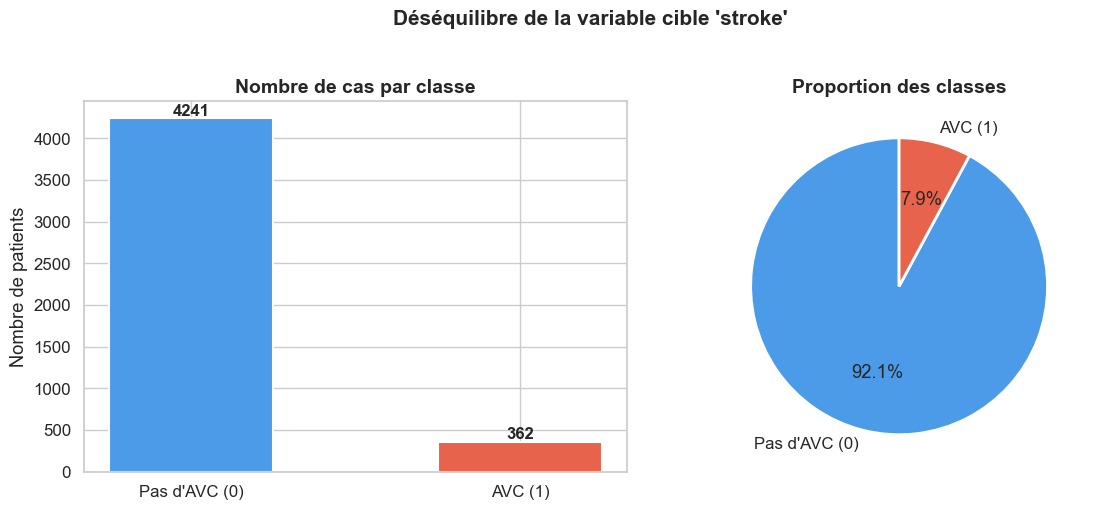

Total patients      : 4603
AVC (stroke=1)      : 362  (7.9%)
Pas d'AVC (stroke=0): 4241  (92.1%)
Ratio déséquilibre  : 1 positif pour 11 négatifs


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df[TARGET].value_counts()
labels = ["Pas d'AVC (0)", 'AVC (1)']
colors = ['#4C9BE8', '#E8634C']

axes[0].bar(labels, counts.values, color=colors,
            edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Nombre de cas par classe')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proportion des classes')

plt.suptitle("Déséquilibre de la variable cible 'stroke'",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

total    = len(df)
n_stroke = counts[1]
print(f'Total patients      : {total}')
print(f'AVC (stroke=1)      : {n_stroke}  ({n_stroke/total*100:.1f}%)')
print(f"Pas d'AVC (stroke=0): {total - n_stroke}  ({(total-n_stroke)/total*100:.1f}%)")
print(f'Ratio déséquilibre  : 1 positif pour {int((total-n_stroke)/n_stroke)} négatifs')

## 8. Distribution des variables catégorielles

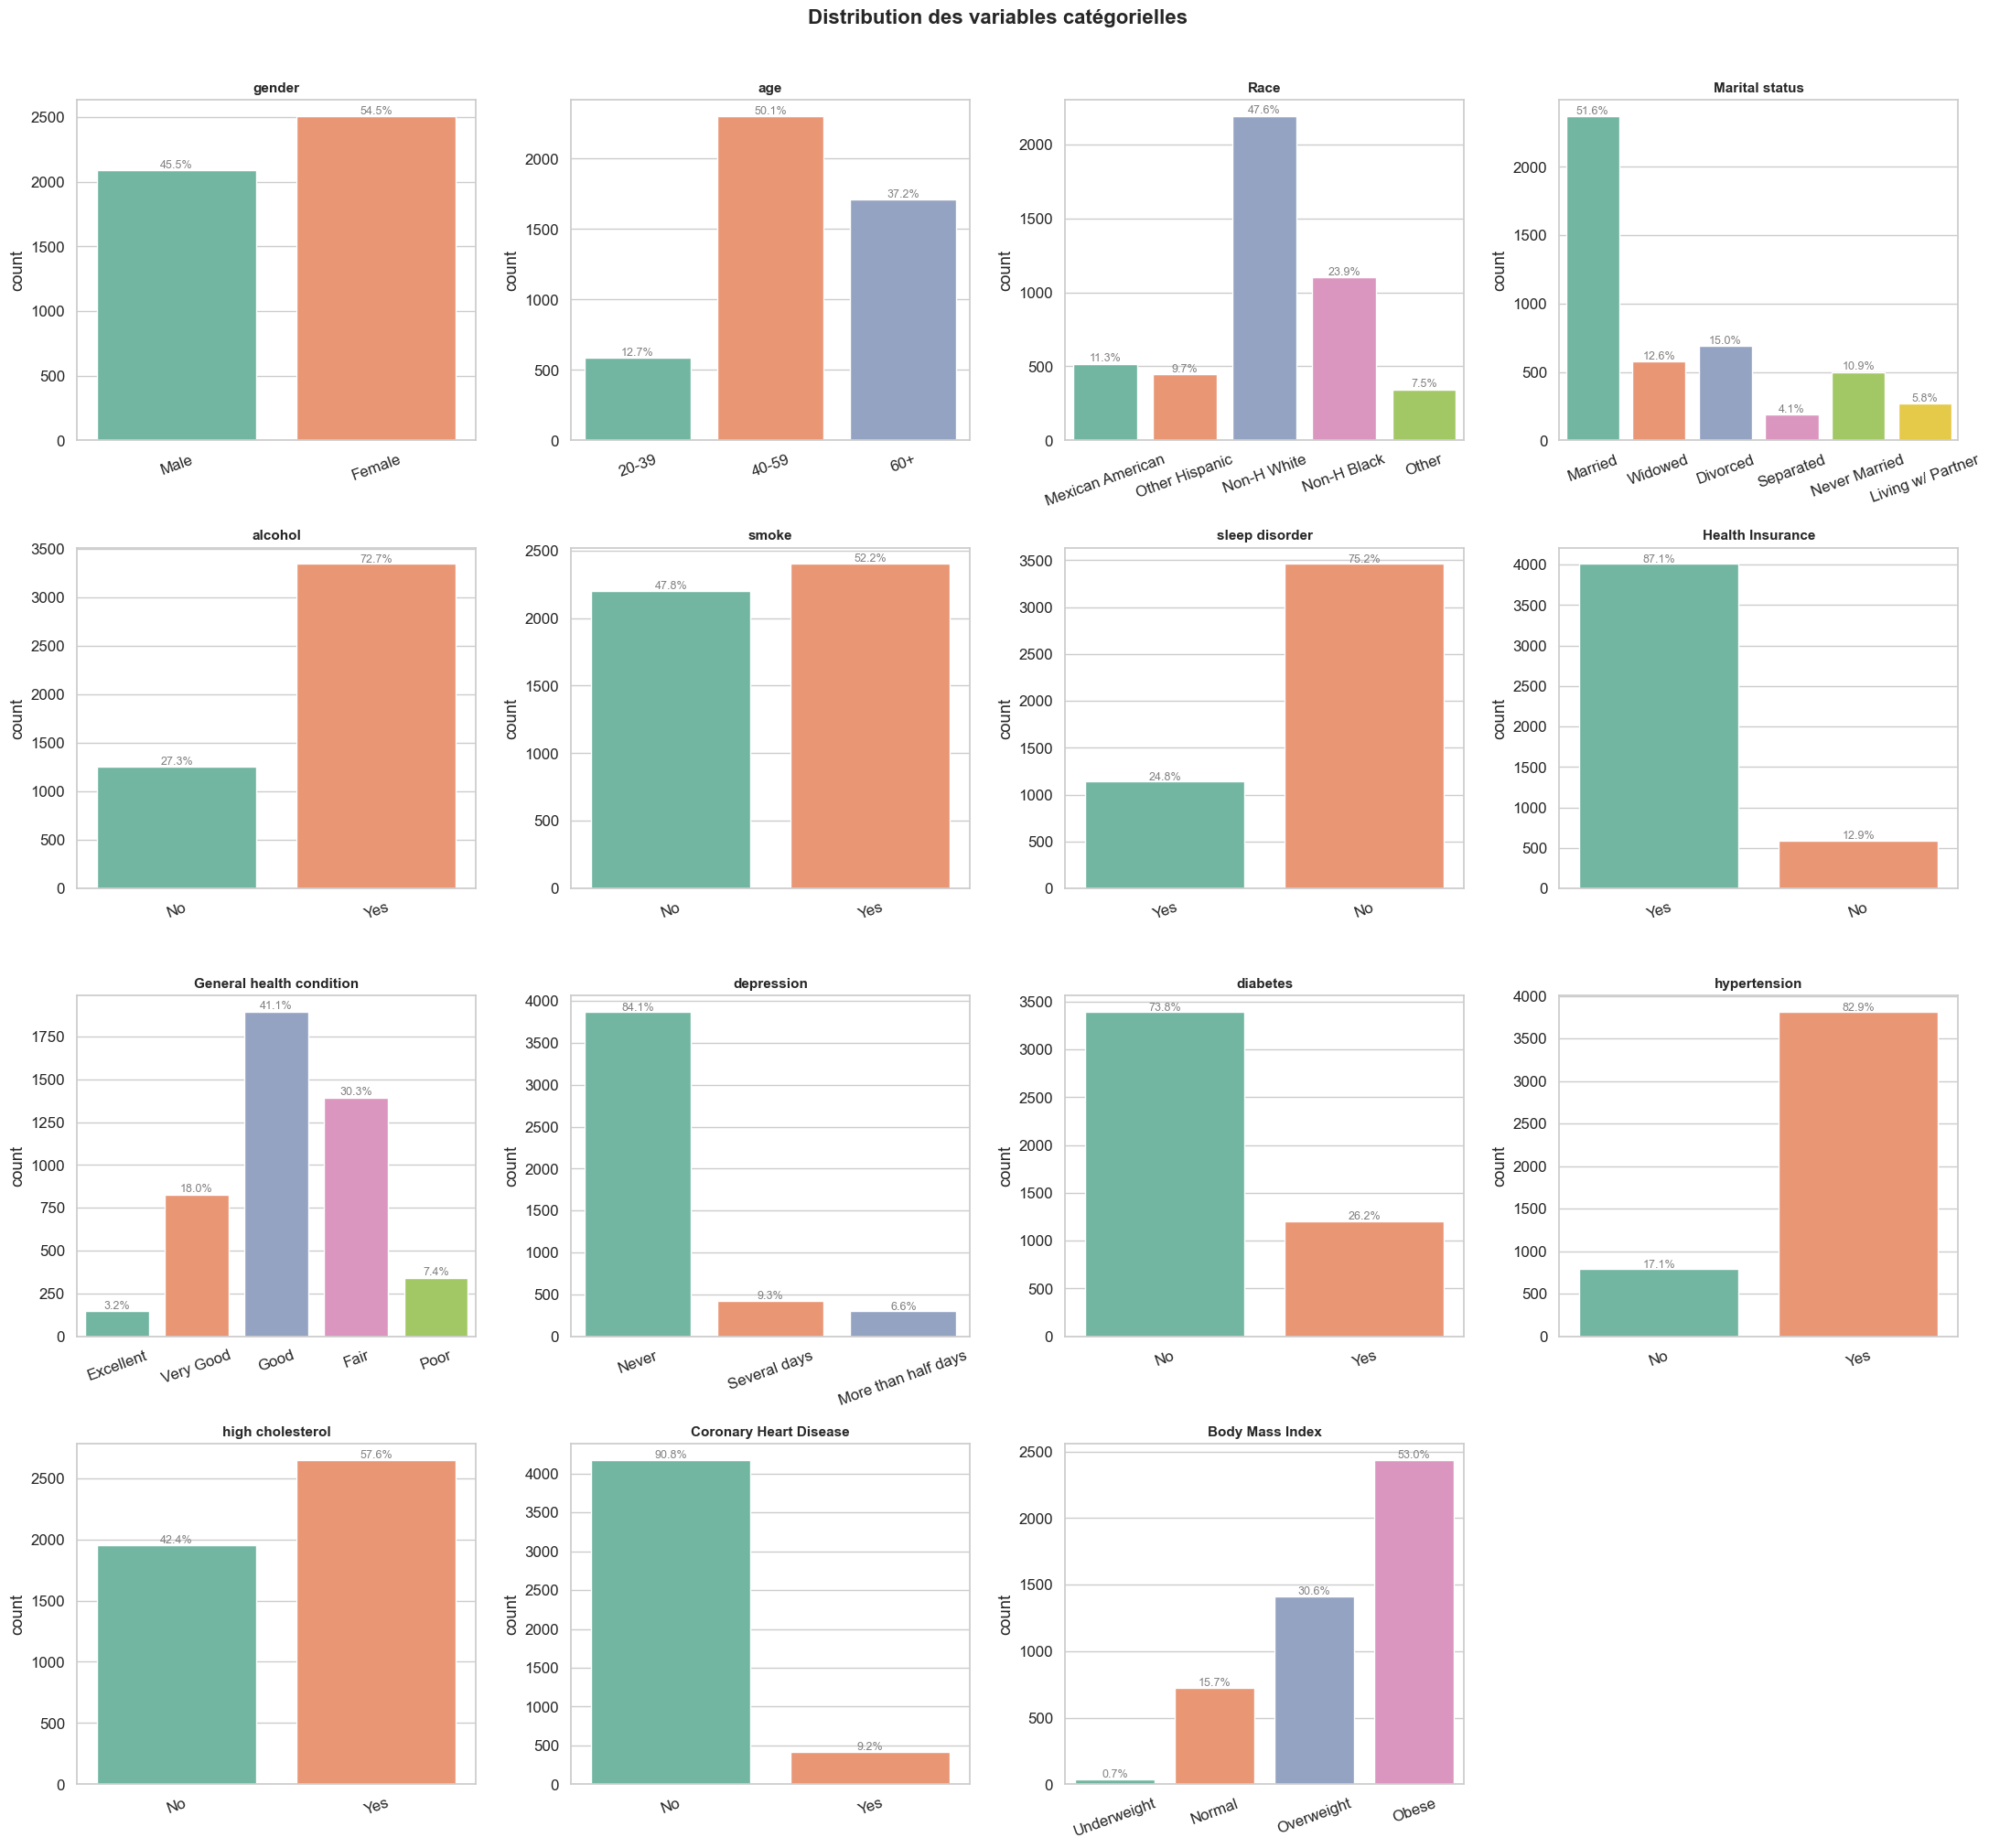

In [8]:
n_cols = 4
n_rows = (len(CATEGORICAL_VARS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_VARS):
    mapped = df[col].map(LABEL_MAPS.get(col, {}))
    order  = list(LABEL_MAPS.get(col, {}).values())

    sns.countplot(x=mapped, ax=axes[i], order=order,
                  palette='Set2', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

    for p in axes[i].patches:
        pct = f"{100 * p.get_height() / total:.1f}%"
        axes[i].annotate(pct,
                         (p.get_x() + p.get_width() / 2, p.get_height() + 15),
                         ha='center', fontsize=9, color='gray')

for j in range(len(CATEGORICAL_VARS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables catégorielles',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Distribution des variables continues

Histogramme + KDE pour chaque variable continue.
Code couleur selon le niveau de skewness :
- Bleu : `|skew| ≤ 1` — distribution normale
- Orange : `1 < |skew| ≤ 2` — asymétrie modérée
- Rouge : `|skew| > 2` — transformation Log1p nécessaire

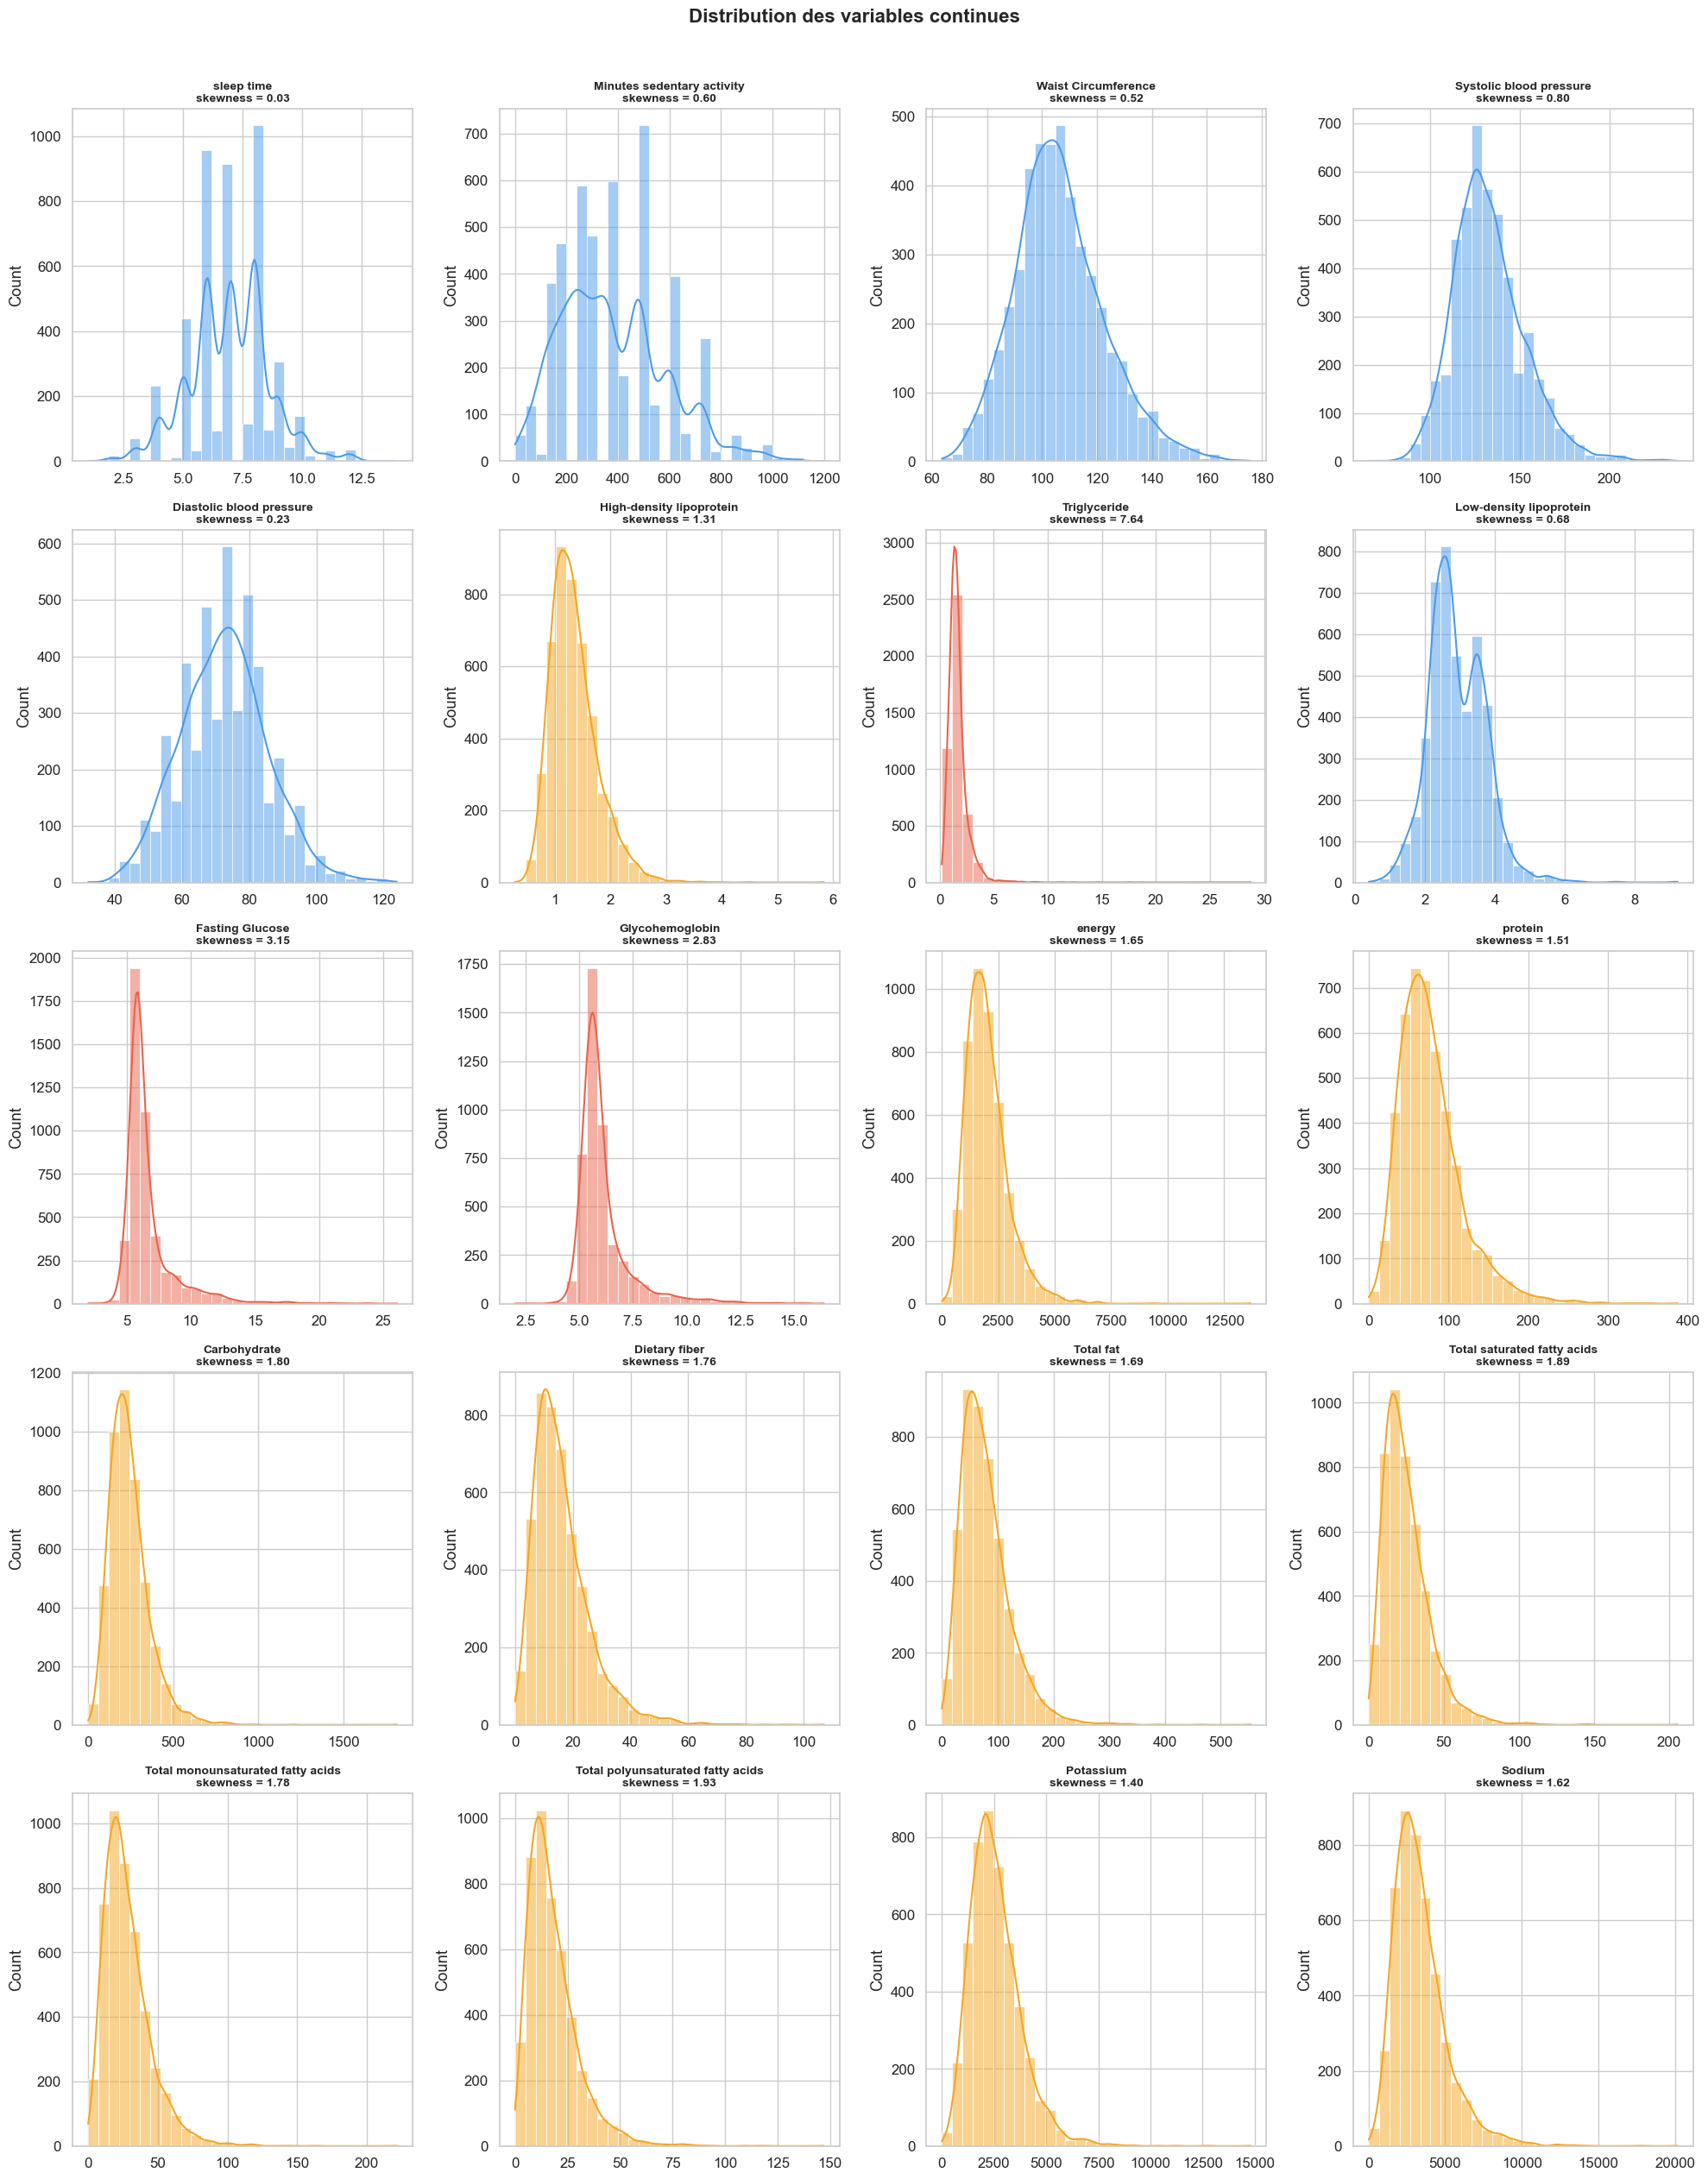

In [9]:
n_cols = 4
n_rows = (len(NUMERICAL_VARS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_VARS):
    skew_val = df[col].skew()

    if abs(skew_val) > 2:
        color = '#E8634C'
    elif abs(skew_val) > 1:
        color = '#F4A623'
    else:
        color = '#4C9BE8'

    sns.histplot(df[col], ax=axes[i], kde=True, color=color,
                 bins=30, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col}\nskewness = {skew_val:.2f}', fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(NUMERICAL_VARS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables continues',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Analyse des Outliers — Boxplots + % quantifié

En V2, on les **quantifie** pour justifier la Winsorization en preprocessing.

Seuils :
- `< 1%` outliers → distribution propre
- `1% – 5%` outliers → à surveiller
- `> 5%` outliers → Winsorization nécessaire

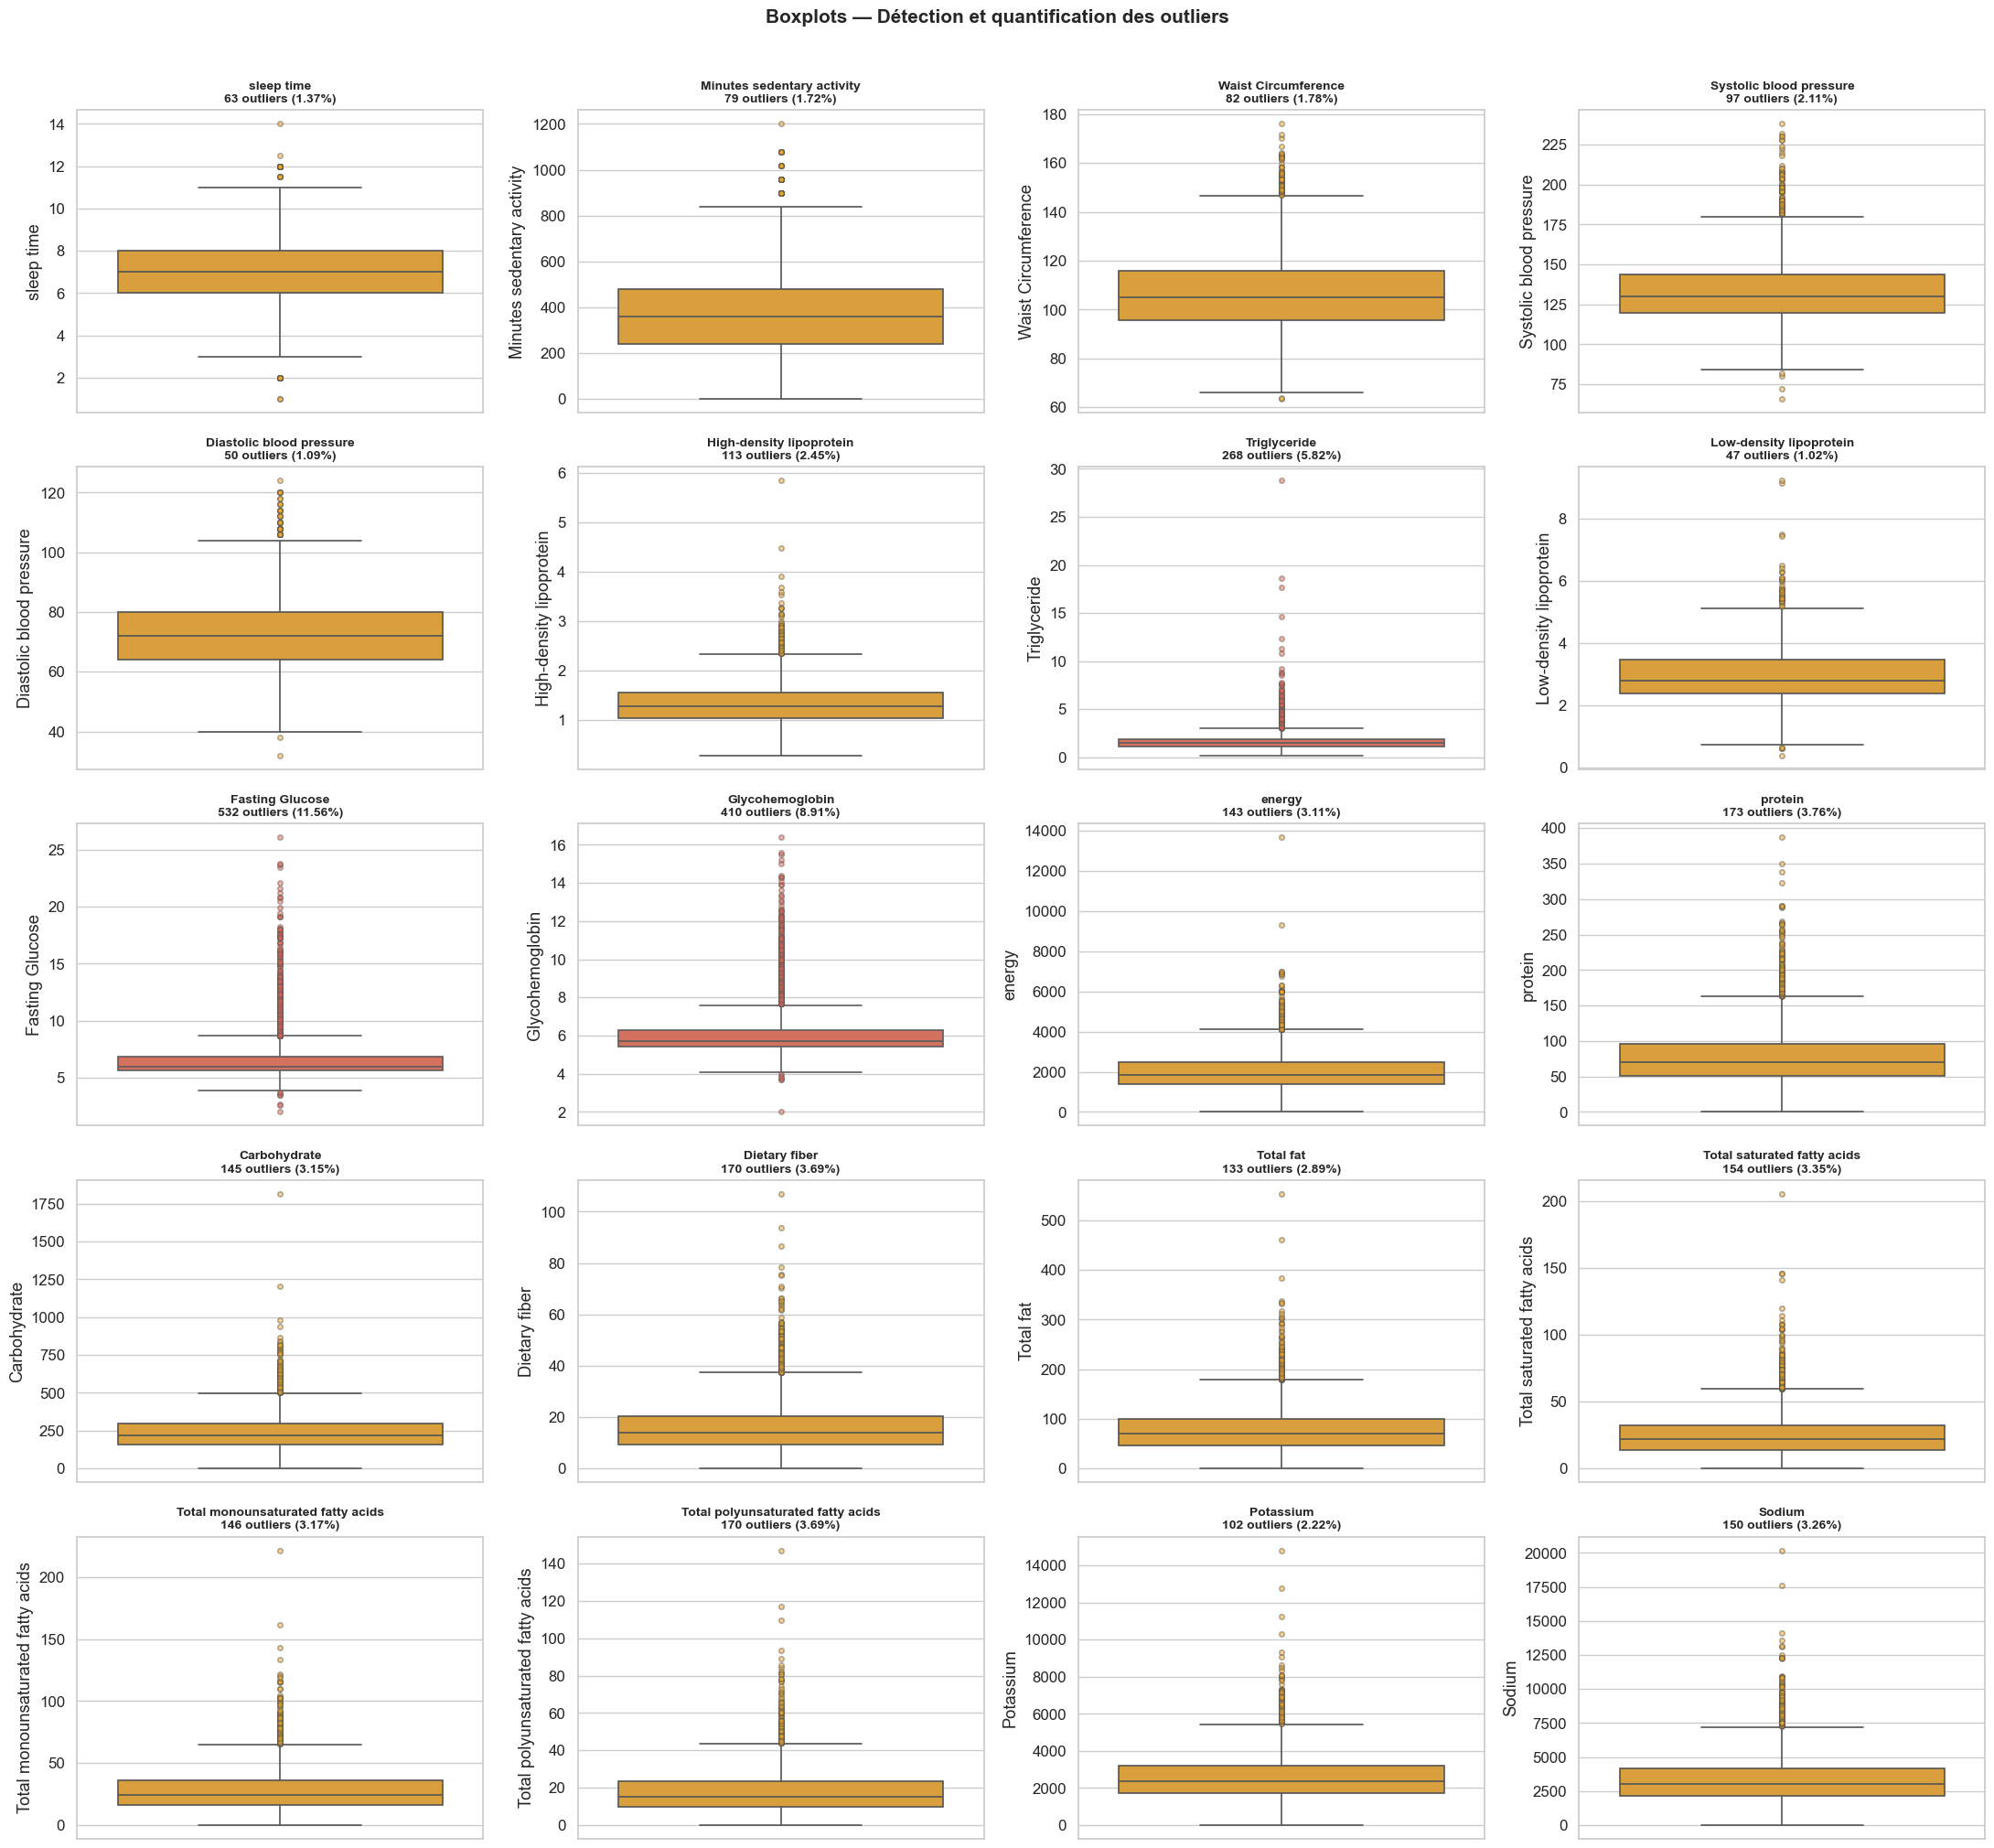


=== Récapitulatif outliers ===
                         Variable  N outliers  % outliers
                  Fasting Glucose         532       11.56
                  Glycohemoglobin         410        8.91
                     Triglyceride         268        5.82
                          protein         173        3.76
Total polyunsaturated fatty acids         170        3.69
                    Dietary fiber         170        3.69
      Total saturated fatty acids         154        3.35
                           Sodium         150        3.26
Total monounsaturated fatty acids         146        3.17
                     Carbohydrate         145        3.15
                           energy         143        3.11
                        Total fat         133        2.89
         High-density lipoprotein         113        2.45
                        Potassium         102        2.22
          Systolic blood pressure          97        2.11
              Waist Circumference       

In [10]:
n_cols = 4
n_rows = (len(NUMERICAL_VARS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(22, 4 * n_rows))
axes = axes.flatten()

outlier_summary = []

for i, col in enumerate(NUMERICAL_VARS):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = round(n_out / len(df) * 100, 2)
    outlier_summary.append({'Variable': col, 'N outliers': n_out, '% outliers': pct})

    color = '#E8634C' if pct > 5 else ('#F4A623' if pct > 1 else '#4C9BE8')

    sns.boxplot(y=df[col], ax=axes[i], color=color,
                flierprops=dict(marker='o', markerfacecolor=color,
                                markersize=4, alpha=0.5),
                linewidth=1.2)
    axes[i].set_title(f'{col}\n{n_out} outliers ({pct}%)', fontsize=10)

for j in range(len(NUMERICAL_VARS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Détection et quantification des outliers',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
outlier_df = pd.DataFrame(outlier_summary).sort_values('% outliers', ascending=False)
print('\n=== Récapitulatif outliers ===')
print(outlier_df.to_string(index=False))
print(f'\n→ Variables avec > 5% outliers (Winsorization prioritaire) :')
print(outlier_df[outlier_df['% outliers'] > 5]['Variable'].tolist())

## 11. Analyse de la Skewness — Variables à transformer

Les variables identifiées ici recevront un **Log1p** en preprocessing.

In [11]:
desc = df[NUMERICAL_VARS].describe().T
desc['skewness'] = df[NUMERICAL_VARS].skew().round(2)
desc['kurtosis'] = df[NUMERICAL_VARS].kurt().round(2)
desc = desc[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].round(2)

def highlight_skew(val):
    if abs(val) > 2:
        return 'background-color: #ffcccc'   # rouge → Log1p nécessaire
    elif abs(val) > 1:
        return 'background-color: #fff3cd'   # orange → à surveiller
    return ''

display(desc.style.applymap(highlight_skew, subset=['skewness']))

# Variables prioritaires
skewed_vars = desc[desc['skewness'].abs() > 2]['skewness'].sort_values(ascending=False)
print('\nVariables fortement asymétriques (|skewness| > 2) — Log1p en preprocessing :')
for col, skew in skewed_vars.items():
    print(f'   {col:<40} skewness = {skew}')
print(f'\n→ {len(skewed_vars)} variables sur {len(NUMERICAL_VARS)} à transformer.')

,mean,std,min,max,skewness,kurtosis
sleep time,6.950000,1.650000,1.000000,14.000000,0.030000,0.480000
Minutes sedentary activity,376.650000,201.400000,0.000000,1200.000000,0.600000,0.010000
Waist Circumference,106.440000,16.310000,63.500000,176.000000,0.520000,0.470000
Systolic blood pressure,132.950000,19.920000,66.000000,238.000000,0.800000,1.500000
Diastolic blood pressure,72.530000,12.860000,32.000000,124.000000,0.230000,0.170000
High-density lipoprotein,1.340000,0.430000,0.280000,5.840000,1.310000,4.740000
Triglyceride,1.660000,1.050000,0.200000,28.780000,7.640000,136.870000
Low-density lipoprotein,2.910000,0.800000,0.390000,9.230000,0.680000,2.460000
Fasting Glucose,6.660000,2.060000,2.000000,26.090000,3.150000,14.190000
Glycohemoglobin,6.090000,1.260000,2.000000,16.400000,2.830000,11.130000



Variables fortement asymétriques (|skewness| > 2) — Log1p en preprocessing :
   Triglyceride                             skewness = 7.64
   Fasting Glucose                          skewness = 3.15
   Glycohemoglobin                          skewness = 2.83

→ 3 variables sur 20 à transformer.


## 12. Matrice de corrélation sur variables numériques + cible

**[NOUVEAU V2]** En V1, la corrélation ne portait que sur `num_cols`.
En V2, on inclut **toutes les variables** (cat + num) pour avoir
une vue complète des relations avec `stroke`.

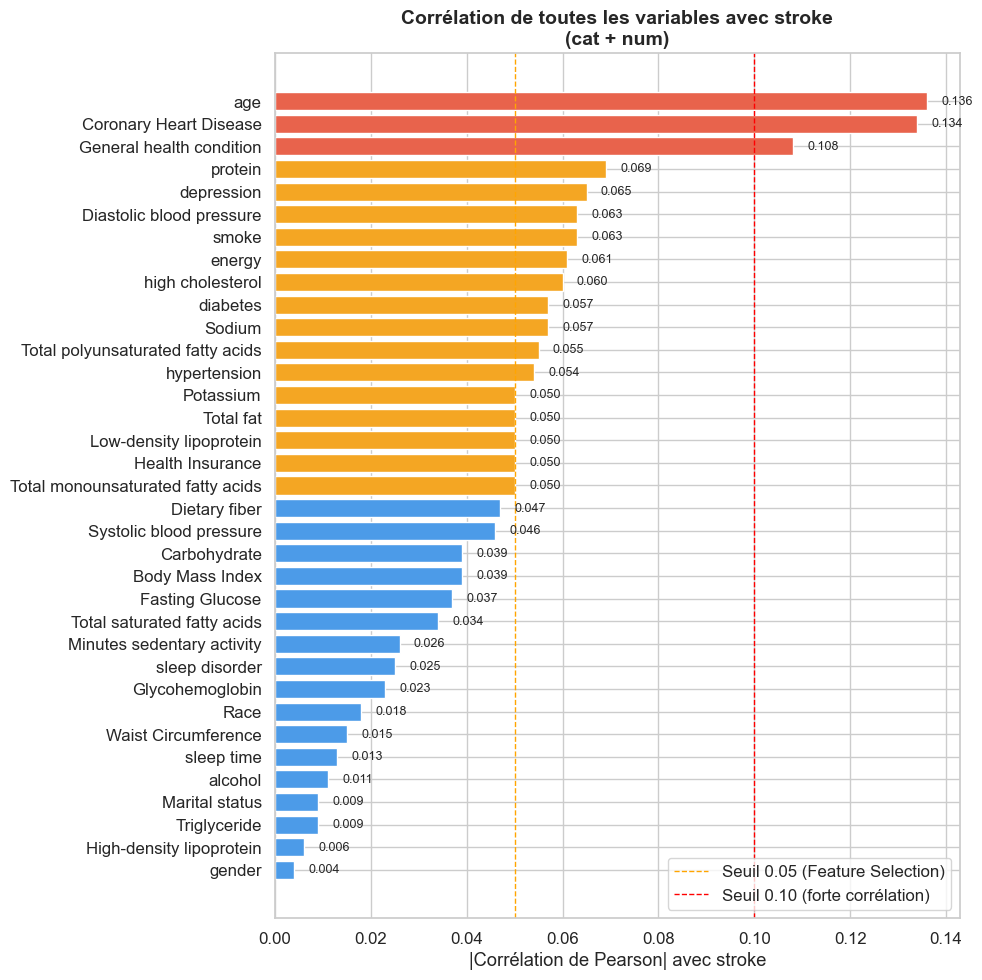


Variables faiblement corrélées avec stroke (|corr| < 0.05) :
['Dietary fiber', 'Systolic blood pressure', 'Carbohydrate', 'Body Mass Index', 'Fasting Glucose', 'Total saturated fatty acids', 'Minutes sedentary activity', 'sleep disorder', 'Glycohemoglobin', 'Race', 'Waist Circumference', 'sleep time', 'alcohol', 'Marital status', 'Triglyceride', 'High-density lipoprotein', 'gender']
→ Ces variables seront candidates à la suppression en Feature Selection (modeling).


In [12]:
# Corrélation de TOUTES les variables avec stroke
all_vars = CATEGORICAL_VARS + NUMERICAL_VARS
corr_with_target = (
    df[all_vars + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 10))

colors = ['#E8634C' if v >= 0.1 else ('#F4A623' if v >= 0.05 else '#4C9BE8')
          for v in corr_with_target.values]

bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors, edgecolor='white')
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=1,
           label='Seuil 0.05 (Feature Selection)')
ax.axvline(x=0.10, color='red',    linestyle='--', linewidth=1,
           label='Seuil 0.10 (forte corrélation)')

for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('|Corrélation de Pearson| avec stroke')
ax.set_title('Corrélation de toutes les variables avec stroke\n(cat + num)',
             fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nVariables faiblement corrélées avec stroke (|corr| < 0.05) :')
print(corr_with_target[corr_with_target < 0.05].index.tolist())
print('→ Ces variables seront candidates à la suppression en Feature Selection (modeling).')

## 13. Heatmap de corrélation complète

**[NOUVEAU V2]** En V1, la heatmap ne couvrait que `num_cols`.
En V2, on visualise les corrélations entre **toutes les variables**
pour identifier la multicolinéarité.


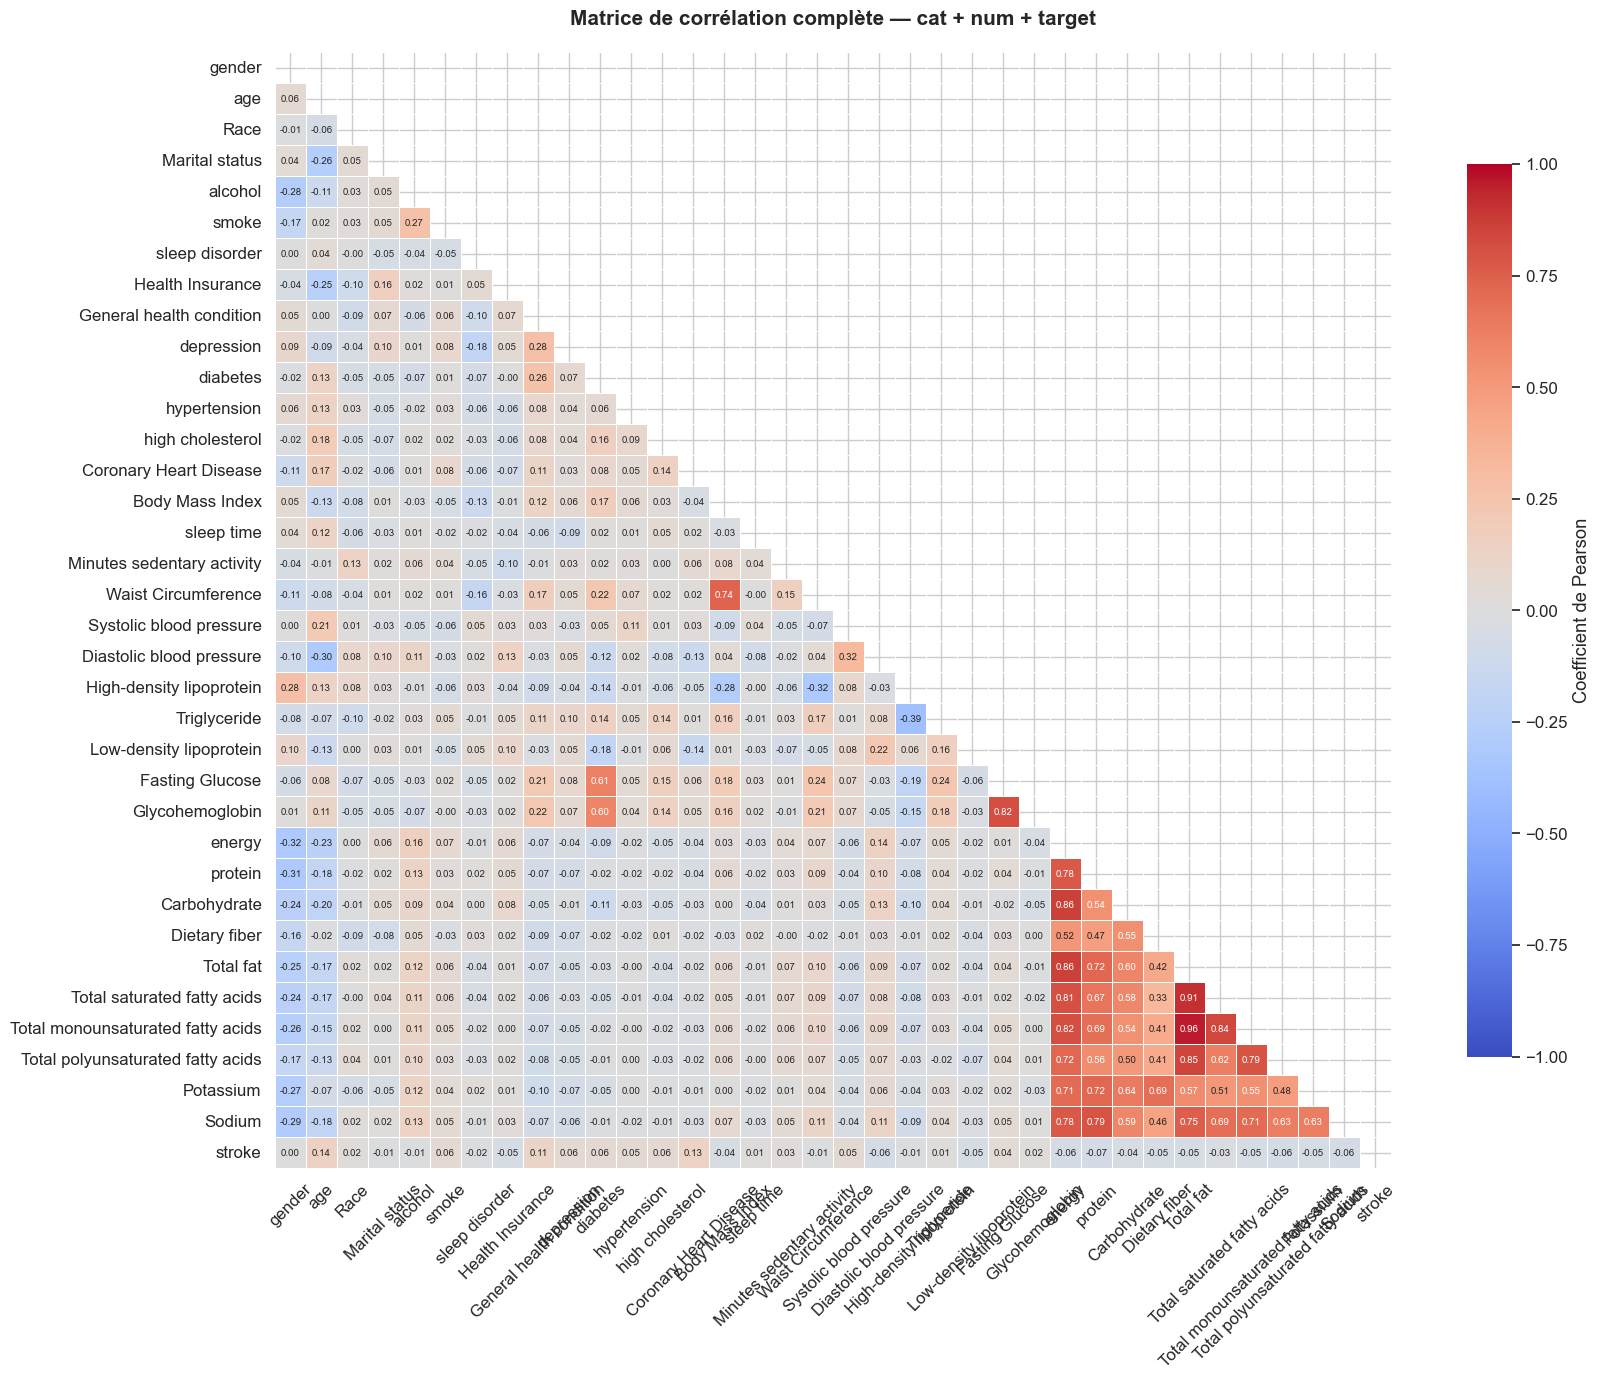


Paires de features fortement corrélées entre elles (|corr| > 0.7) :
   Total fat                           ↔ Total monounsaturated fatty acids   corr = 0.965
   Total fat                           ↔ Total saturated fatty acids         corr = 0.915
   Total fat                           ↔ energy                              corr = 0.863
   Carbohydrate                        ↔ energy                              corr = 0.86
   Total fat                           ↔ Total polyunsaturated fatty acids   corr = 0.851
   Total monounsaturated fatty acids   ↔ Total saturated fatty acids         corr = 0.836
   Fasting Glucose                     ↔ Glycohemoglobin                     corr = 0.818
   Total monounsaturated fatty acids   ↔ energy                              corr = 0.816
   Total saturated fatty acids         ↔ energy                              corr = 0.808
   Total monounsaturated fatty acids   ↔ Total polyunsaturated fatty acids   corr = 0.794
   Sodium                       

In [13]:
corr_matrix = df[all_vars + [TARGET]].corr().round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7},
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de Pearson'}
)
ax.set_title('Matrice de corrélation complète — cat + num + target',
             fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Identifier les paires fortement corrélées entre features (hors target)
corr_features = df[all_vars].corr().abs()
np.fill_diagonal(corr_features.values, 0)
high_corr_pairs = [
    (c1, c2, round(corr_features.loc[c1, c2], 3))
    for c1 in corr_features.columns
    for c2 in corr_features.columns
    if c1 < c2 and corr_features.loc[c1, c2] > 0.7
]
print('\nPaires de features fortement corrélées entre elles (|corr| > 0.7) :')
if high_corr_pairs:
    for c1, c2, val in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'   {c1:<35} ↔ {c2:<35} corr = {val}')
    print('→ Ces paires seront analysées par VIF en modeling.')
else:
    print('   Aucune paire avec |corr| > 0.7 détectée.')

## 14. Sauvegarde — `features.json`

Les listes `CATEGORICAL_VARS` et `NUMERICAL_VARS` sont sauvegardées
dans `src/features.json` via `save_features()` depuis `config.py`.

Ces listes seront chargées par `load_features()` dans :
- `2_Preprocessing_v2.ipynb`
- `3_Modeling_v2.ipynb`

In [14]:
save_features(CATEGORICAL_VARS, NUMERICAL_VARS)
print('\nEDA V2 terminée.')

features.json sauvegarde dans ./src/features.json
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables
  all_features     : 35 variables

EDA V2 terminée.
